# Plotting Right Singular Vectors

In [ ]:
from ast import literal_eval

import einops
import matplotlib.pyplot as plt
import matrepr
import numpy as np
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from pydmd import DMD, FbDMD
from safetensors.torch import load_file, load_model, save_model
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
from torcheval.metrics import MulticlassAccuracy
from torchvision import datasets, transforms

from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import string

In [ ]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

In [ ]:
def hankel(X, lag=1, delays=1):
    """
    Given a data matrix X as a 1-D or 2-D numpy.ndarray, uses the `delays`
    and `lag` attributes to return the data as a 2-D Hankel matrix.

    :param X: (m,) or (n, m) array of data.
    :type X: numpy.ndarray
    :return: Hankel matrix of data.
    :rtype: numpy.ndarray
    """
    if not isinstance(X, np.ndarray) or X.ndim > 2:
        raise ValueError("Data must be a 1-D or 2-D numpy array.")
    if X.ndim == 1:
        X = X[None]
    n, m = X.shape

    # Check that the input data contains enough observations.
    m_min = lag * (delays - 1) + 1
    if m < m_min:
        raise ValueError(
            "Not enough snapshots provided for "
            f"{delays} delays and lag {lag}. "
            f"Please provide at least {m_min} snapshots."
        )

    Hm = m - ((delays - 1) * lag)
    H = np.empty((n * delays, Hm))
    for i in range(delays):
        H[i * n : (i + 1) * n] = X[:, i * lag : i * lag + Hm]

    return H

In [ ]:
LAYER_START = 5

In [ ]:
file_path = f"../saved_weights/mnist_start{LAYER_START}_states.safetensors"
data = load_file(file_path)

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_TRAJECTORIES = literal_eval(metadata["num_trajectories"])
NUM_STATES = literal_eval(metadata["num_states"])
NUM_ITERATIONS = literal_eval(metadata["num_iterations"])

# Updates
NUM_TRAJECTORIES = 500
LIST_NUM_DELAYS =  [1, 10, 50]
# LIST_NUM_DELAYS = [1, 5, 10, 50]

In [ ]:
train_states = reshape_append_time(
    data["train_states"][:NUM_ITERATIONS, :NUM_TRAJECTORIES, :NUM_STATES]
).cuda()

In [ ]:
rsv_list = []
lsv_list = []
for i, num_delays in enumerate(LIST_NUM_DELAYS): 
    print(f"Computing SVD {i}...")
    hankel_matrix = hankel(train_states.cpu().numpy(), lag=1, delays=num_delays)
    U, S, Vh = torch.linalg.svd(torch.from_numpy(hankel_matrix).cuda(1), full_matrices=False)
    lsv_list.append(U)
    rsv_list.append(Vh)

Computing SVD 0...
Computing SVD 1...


Computing SVD 2...


In [ ]:
hankel_matrix = hankel(train_states.cpu().numpy(), lag=1, delays=1)
mprint(hankel_matrix)

<256×6000, 1536000 'float64' elements, array>
        0      1      2      3       4          5996    5997    5998    5999
    ┌                                                                         ┐
  0 │   0    171.6    0    0.3821    0    ...  93.18   37.88     0      313   │
  1 │   0      0      0      0     31.38  ...    0     250.9     0       0    │
  2 │   0    2.37     0      0     142.4  ...  31.09   135.8   113.4     0    │
  3 │   0      0    152.9    0     9.357  ...  128.9   46.28     0       0    │
  4 │ 28.69  52.84    0      0     11.3   ...  10.86     0       0       68   │
    │   :      :      :      :       :    ...    :       :       :       :    │
251 │   0      0    34.79    0       0    ...    0     25.98     0       -1   │
252 │   0      0    275.4    0       0    ...  207.1   1.933     0       -1   │
253 │   0    30.71    0      0       0    ...  66.44   30.79   8.171     -1   │
254 │   0    9.732  234.9    0     175.7  ...  191.9     0     154.5     -1  

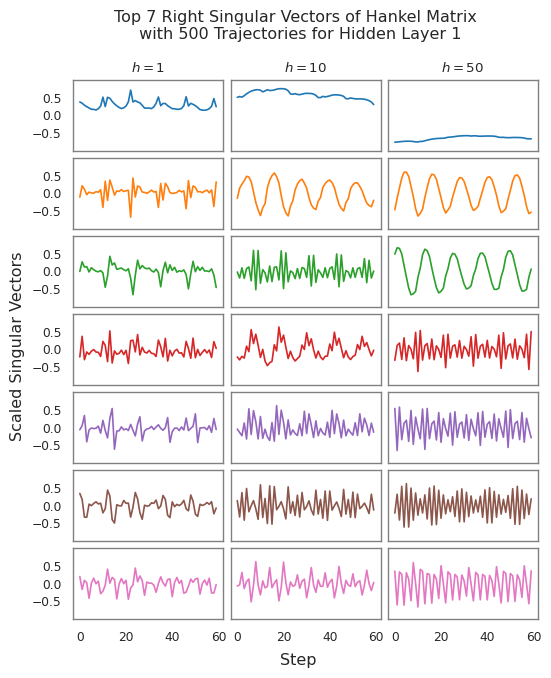

In [ ]:
# Number of top right singular vectors to plot
k = 7

# Number of Vh matrices
n = len(rsv_list)

# Set Seaborn context and style
sns.set_context("paper")
sns.set_style("white")

# Grab colors using Seaborn's color palette
colors = sns.color_palette("tab10", k)

# Plotting right singular vectors
fig, axs = plt.subplots(k, n, figsize=(2*n, 1*k), sharex=True, sharey=True)

keys = list(string.ascii_uppercase[2:4])

for j, Vh in enumerate(rsv_list):
    # Transpose Vh
    V = Vh.T

    # Normalize singular vector between [-1, 1]
    V_normalized = V / torch.max(torch.abs(V), dim=0).values

    for i in range(k):
        ax = axs[i,j]

        ax.plot(V_normalized[:60, i].cpu().numpy(), color=colors[i])
        ax.set_ylim([-1, 1])  # Set the y-axis limits to [-1, 1])
        
        # # Add row title for the first column
        # if j == 0:
        #     axs[i, j].set_ylabel(f'Top {i+1}', fontsize=12)

        ax.set_yticks([-0.5, 0, 0.5])

        # Add column title for the first row
        if i == 0:
            ax.set_title(f'$h={LIST_NUM_DELAYS[j]}$')
            # ax.text(0.00, 1.07, keys[j], transform=ax.transAxes, weight='bold')
        
        # Make the edges of the plot box light gray
        for spine in axs[i,j].spines.values():
            spine.set_color('gray')

# Add figure title
fig.suptitle(f'Top {k} Right Singular Vectors of Hankel Matrix \n with 500 Trajectories for Hidden Layer {(LAYER_START+1)//2}', y=0.98)

# Add axis labels
fig.supxlabel("Step", y=0.04)
fig.supylabel("Scaled Singular Vectors",x=0.02)

plt.subplots_adjust(wspace=0.05, hspace=0.1)  # Modify these values to control spacing
plt.savefig(f'mnist_top_rsv_start{LAYER_START}.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()
